# Analyze results

Here we wil analyze the sex difference results

In [1]:
import os
import pandas as pd
import numpy as np
import clarite as cl
import matplotlib.pyplot as plt

rpy2 ModuleSpec(name='rpy2', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7ff3b615acd0>, origin='/home/tomas/anaconda3/envs/py_clarite/lib/python3.7/site-packages/rpy2/__init__.py', submodule_search_locations=['/home/tomas/anaconda3/envs/py_clarite/lib/python3.7/site-packages/rpy2'])


In [2]:
#### SET PATHS
os.chdir('..')
mainpath = os.getcwd()
datapath = os.path.join(mainpath, 'Data')
respath  = os.path.join(mainpath, 'Results')

In [3]:
# Load data
os.chdir(respath)
nhanes_res = pd.read_csv('Difference_test.csv').rename(columns={'pvalue_difference':'pvalue'}).set_index(['Variable','Phenotype'])

os.chdir(os.path.join(datapath, 'nh_99-06'))
var_description = pd.read_csv('VarDescription.csv')\
                     .drop_duplicates()\
                     .set_index('var')
# Convert variable descriptions to a dictionary for convenience
var_descr_dict = var_description['var_desc'].to_dict()
var_category   = var_description['category'].to_dict()

## Decision tree

1. For the difference-wide analysis, retain those significant (bonferroni corrected) that have only opposite effects
2. For the filtering analysis, first filter for those significant on main effect (bonferroni corrected) and retain only those with everything except opposite effects

In [4]:
sig       = nhanes_res['pvalue_diff_bonferroni'] < 0.05
diff_wide = nhanes_res[sig]

In [5]:
# Main decision tree to retain only opposite effects
both_sig = ( diff_wide['pvalue_f'] < 0.05 ) & ( diff_wide['pvalue_m'] < 0.05 ) # Both need to be significant
opposite = diff_wide.loc[:,'Beta_m'] * diff_wide.loc[:,'Beta_f'] < 0 # Need to point in different directions
keep = both_sig & opposite

In [6]:
# Final dataset for those effects that are different with opposite effects
nhanes_qual = diff_wide[keep]
nhanes_qual

Variable_type  Weight  Converged        N  LRT_pvalue  \
Variable  Phenotype                                                         
LBXODT    LBDMONO      continuous     NaN       True   3849.0         NaN   
URXUPT    LBXMOPCT     continuous     NaN       True   5879.0         NaN   
LBXMIR    LBXMOPCT     continuous     NaN       True   4004.0         NaN   
URXUPT    LBXSTP       continuous     NaN       True   5803.0         NaN   
URXUBE    LBXSAPSI     continuous     NaN       True   5809.0         NaN   
...                           ...     ...        ...      ...         ...   
LBXVST    LBXSCLSI     continuous     NaN       True   4588.0         NaN   
URXUPT    LBXCRP       continuous     NaN       True   5852.0         NaN   
          LBXNEPCT     continuous     NaN       True   5879.0         NaN   
          LBXBAP       continuous     NaN       True   3593.0         NaN   
age_44_65 LBXSPH           binary     NaN       True  17855.0         NaN   

                     Diff_AIC        SE      Beta        pvalue  \
Variable  Phenotype                                               
LBXODT    LBDMONO         NaN  0.008912 -0.025198  9.035854e-95   
URXUPT    LBXMOPCT        NaN  0.085276  1.764418  5.367414e-62   
LBXMIR    LBXMOPCT        NaN  0.007461  0.032659  3.115504e-27   
URXUPT    LBXSTP          NaN  0.201302  0.741645  1.094113e-23   
URXUBE    LBXSAPSI        NaN  0.003597  0.016002  9.530332e-20   
...                       ...       ...       ...           ...   
LBXVST    LBXSCLSI        NaN  0.018612 -0.025637  7.674061e-01   
URXUPT    LBXCRP          NaN  0.042648  0.037697  8.665822e-01   
          LBXNEPCT        NaN  0.160183 -0.499347  8.718500e-01   
          LBXBAP          NaN  0.381712  4.472382  8.994517e-01   
age_44_65 LBXSPH          NaN  0.001768 -0.001642  9.812208e-01   

                     Variable_pvalue  ...      SE_m    Beta_m       pvalue_m  \
Variable  Phenotype                   ...                                      
LBXODT    LBDMONO       9.035854e-95  ...  0.015295  0.047953   1.717675e-03   
URXUPT    LBXMOPCT      5.367414e-62  ...  0.089556  2.005015  5.111694e-111   
LBXMIR    LBXMOPCT      3.115504e-27  ...  0.021171 -0.060391   4.336768e-03   
URXUPT    LBXSTP        1.094113e-23  ...  0.223844  1.718794   1.609015e-14   
URXUBE    LBXSAPSI      9.530332e-20  ...  0.004419  0.031195   1.667265e-12   
...                              ...  ...       ...       ...            ...   
LBXVST    LBXSCLSI      7.674061e-01  ...  0.025776  0.068530   7.844223e-03   
URXUPT    LBXCRP        8.665822e-01  ...  0.050606 -0.168966   8.412294e-04   
          LBXNEPCT      8.718500e-01  ...  0.175345 -0.981953   2.141970e-08   
          LBXBAP        8.994517e-01  ...  0.589228 -1.409764   1.673131e-02   
age_44_65 LBXSPH        9.812208e-01  ...  0.002667 -0.010996   3.733764e-05   

                     Variable_pvalue_m     N_m   pvalue_diff   SE_diff  \
Variable  Phenotype                                                      
LBXODT    LBDMONO         1.717675e-03  1819.0  3.990612e-09  0.018820   
URXUPT    LBXMOPCT       5.111694e-111  2873.0  1.433420e-18  0.293174   
LBXMIR    LBXMOPCT        4.336768e-03  1900.0  2.646401e-06  0.022622   
URXUPT    LBXSTP          1.609015e-14  2838.0  1.835341e-23  0.511832   
URXUBE    LBXSAPSI        1.667265e-12  2844.0  3.222058e-09  0.007608   
...                                ...     ...           ...       ...   
LBXVST    LBXSCLSI        7.844223e-03  2175.0  1.285894e-07  0.037259   
URXUPT    LBXCRP          8.412294e-04  2860.0  3.295681e-14  0.094007   
          LBXNEPCT        2.141970e-08  2873.0  1.320376e-11  0.431073   
          LBXBAP          1.673131e-02  1769.0  3.112374e-39  0.773472   
age_44_65 LBXSPH          3.733764e-05  8611.0  2.800499e-06  0.003562   

                     Beta_diff  Variable_pvalue_diff  pvalue_diff_bonferroni  
Variable  Phenotype                                            

In [7]:
# Filter based on nominal pvalue of overall effect
pt = 0.05 #/sum(~nhanes_res['pvalue'].isna()) #nominal p-value
diff_filter = nhanes_res[nhanes_res['pvalue'] < pt]

In [8]:
# Filter of difference test based on bonferroni correction
pt = 0.05/len(diff_filter) 
diff_filter = diff_filter[diff_filter['pvalue_diff'] < pt]

In [9]:
both_sig = ( diff_filter['pvalue_f'] < 0.05 ) & ( diff_filter['pvalue_m'] < 0.05 ) # Both need to be significant
same     = diff_filter.loc[:,'Beta_m'] * diff_filter.loc[:,'Beta_f'] > 0 # Need to point in different directions
one_sig  = ( ( diff_filter['pvalue_f'] < 0.05 ) & ( diff_filter['pvalue_m'] > 0.05 ) ) | ( ( diff_filter['pvalue_f'] > 0.05 ) & ( diff_filter['pvalue_m'] < 0.05 ) )# Only one significant

# Pure effect (only one significant)
nhanes_pure = diff_filter[one_sig]

# Quantitative effect (significant in both, and same direction)
nhanes_quant = diff_filter[same & both_sig]

In [10]:
# Save datasets 
os.chdir(respath)
nhanes_qual.to_csv('Difference_Qualitative.csv')
nhanes_quant.to_csv('Difference_Quantitative.csv')
nhanes_pure.to_csv('Difference_Pure.csv')

## Manhattan plots

- First, a plot showing the effects in men and women 

In [11]:
vals_m = ['Variable_type', 'Weight', 'Converged', 'N_m', 'LRT_pvalue', 'Diff_AIC', 'SE_m', 'Beta_m', 'pvalue_m', 'Variable_pvalue_m']
vals_f = ['Variable_type', 'Weight', 'Converged', 'N_f', 'LRT_pvalue', 'Diff_AIC', 'SE_f', 'Beta_f', 'pvalue_f', 'Variable_pvalue_f']

def divide_bysex(dat, vals, correction=True):
    temp    = dat.dropna(subset=['pvalue_diff'])
    new_dat = temp.loc[:,vals].rename(columns={vals[3]:'N', 
                                               vals[6]:'SE',
                                               vals[7]:'Beta',
                                               vals[8]:'pvalue',
                                               vals[9]:'Variable_pvalue'})
    new_dat.loc[new_dat['pvalue'] == 0, 'pvalue'] = 1e-268
    if correction:
        cl.analyze.add_corrected_pvalues(new_dat)
    return(new_dat)

plot_m = divide_bysex(nhanes_res, vals_m)
plot_f = divide_bysex(nhanes_res, vals_f)

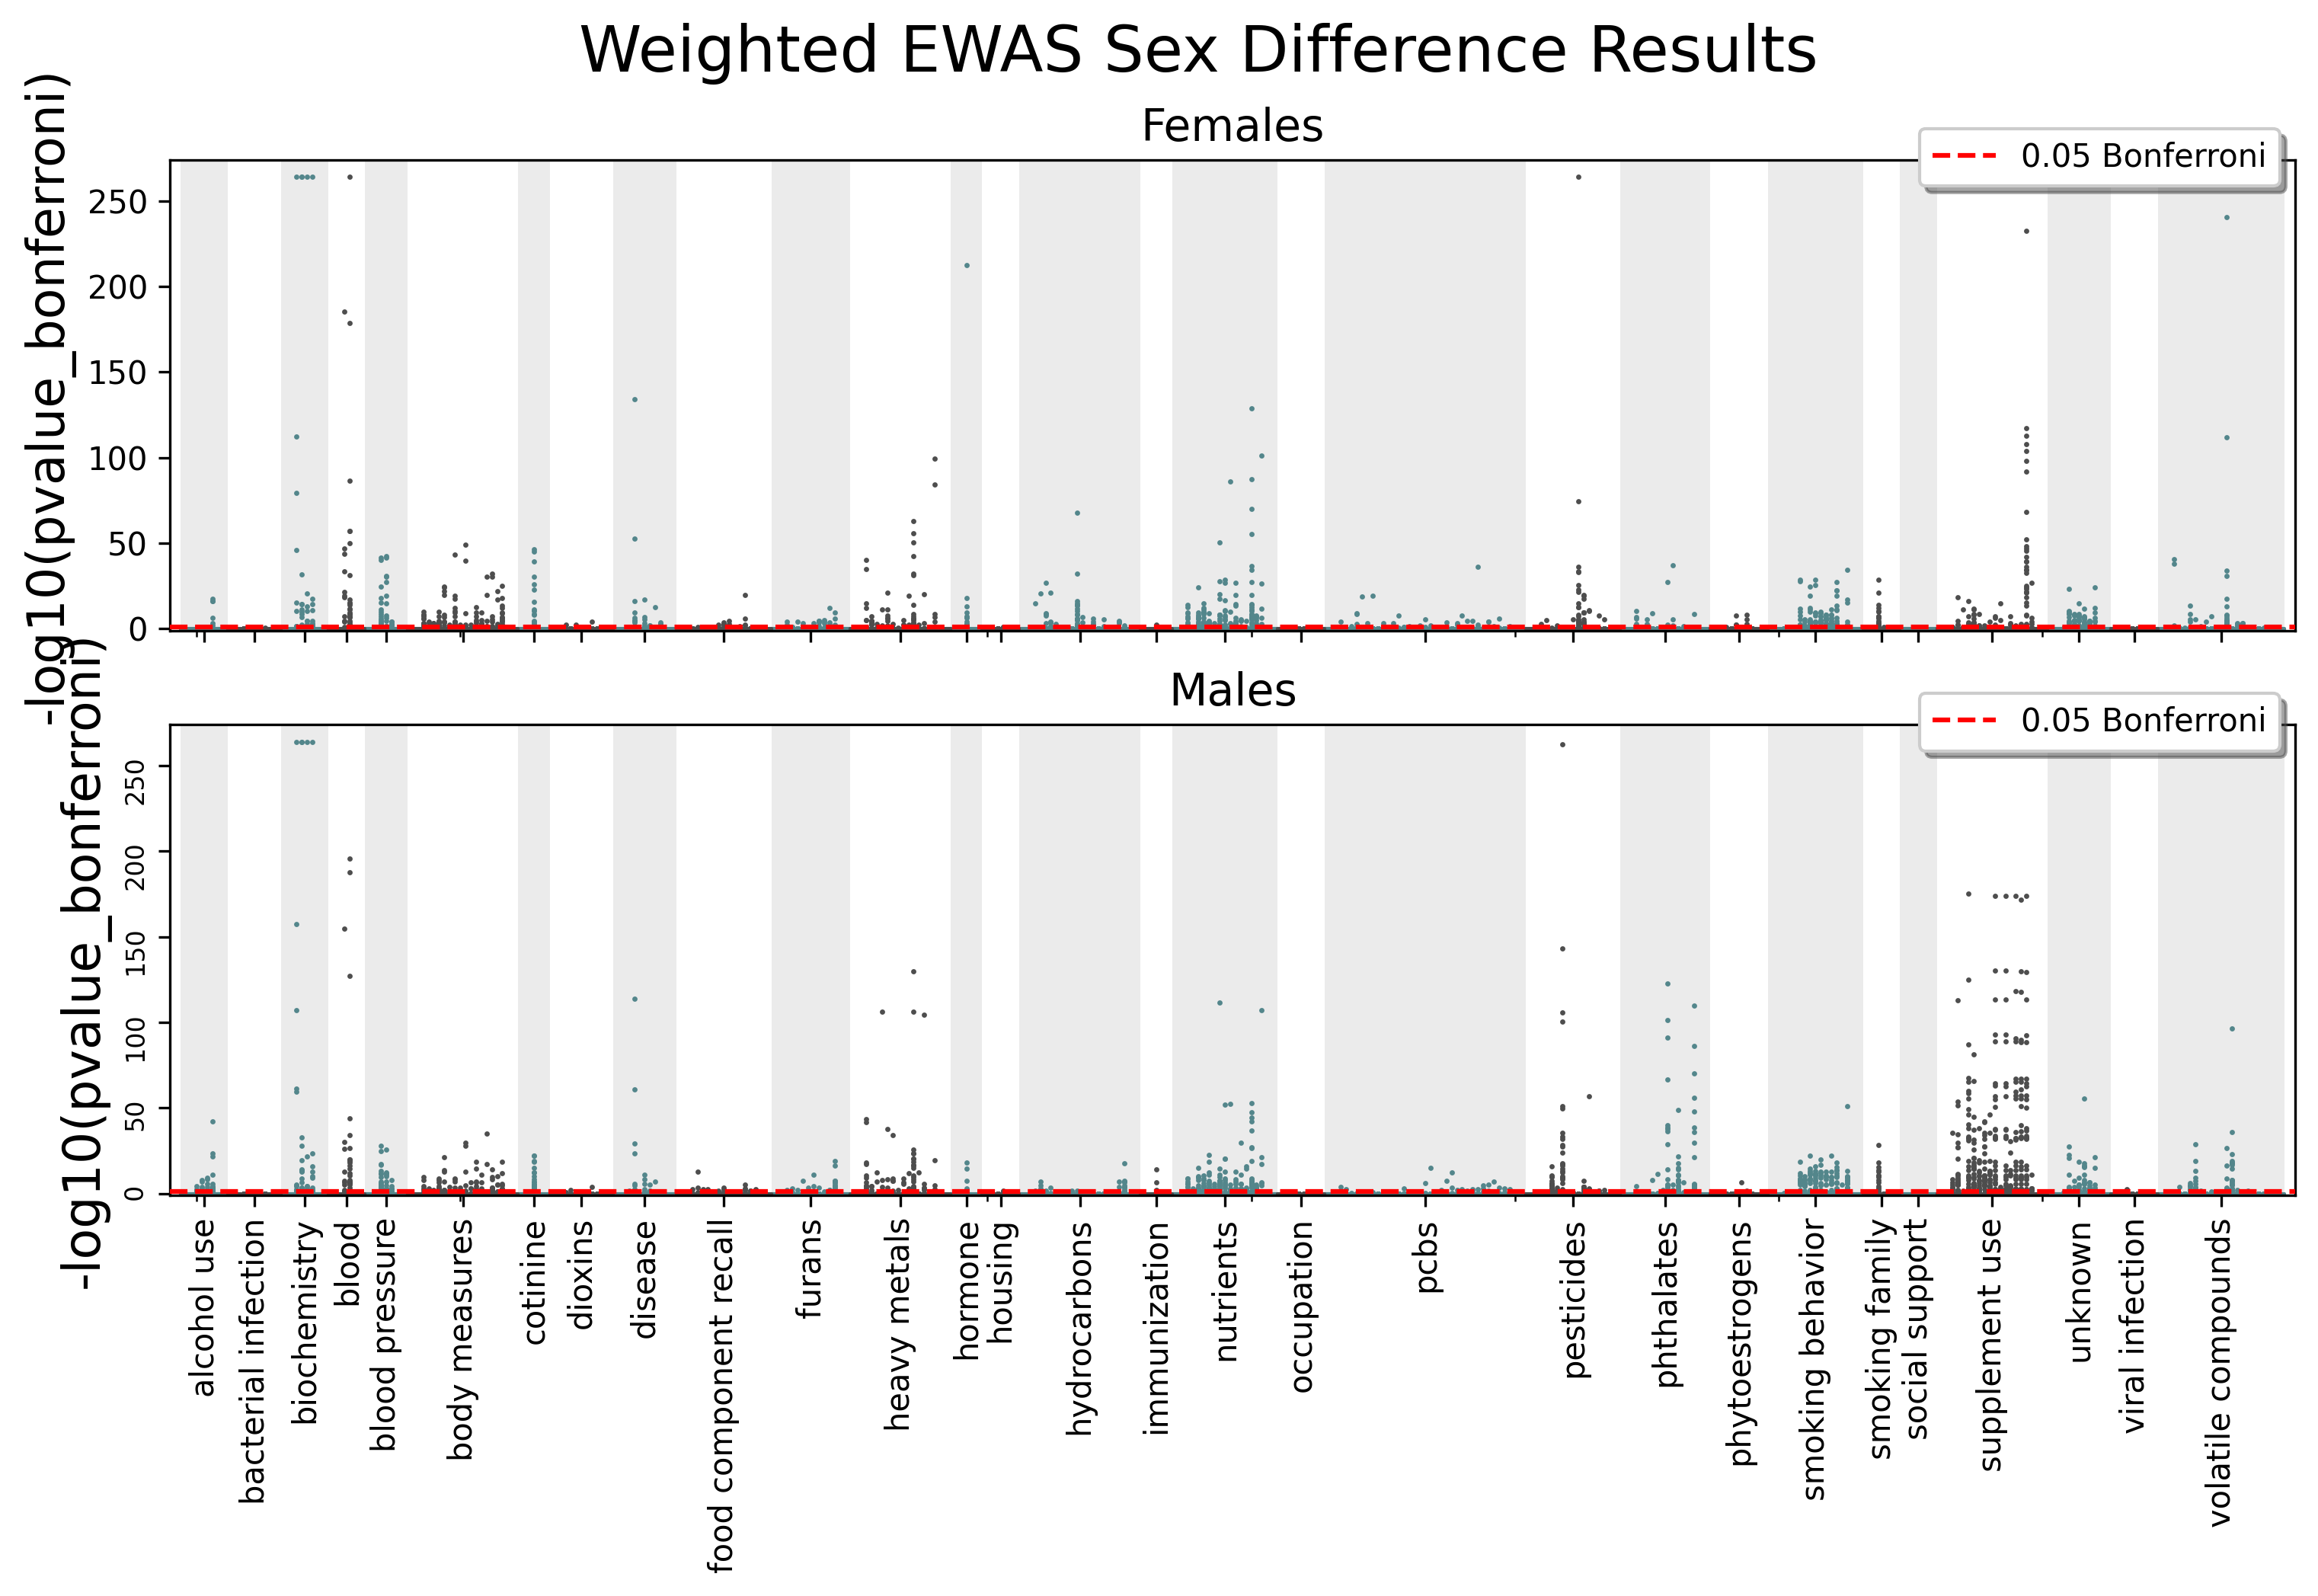

In [12]:
fig = plt.figure(figsize=(12,6), dpi=300)
cl.plot.manhattan_bonferroni({'Females': plot_f, 'Males':plot_m}, num_labeled=0,
                             categories=var_category, 
                             title="Weighted EWAS Sex Difference Results",
                             figure=fig)

Next, a Manhattan plot showing the pvalue of the difference between sexes

In [13]:
vals_diff = ['Variable_type', 'Weight', 'Converged', 'N', 'LRT_pvalue', 'Diff_AIC', 'SE', 'Beta', 'pvalue_diff', 'Variable_pvalue_diff']
plot_diff = divide_bysex(nhanes_res, vals_diff)

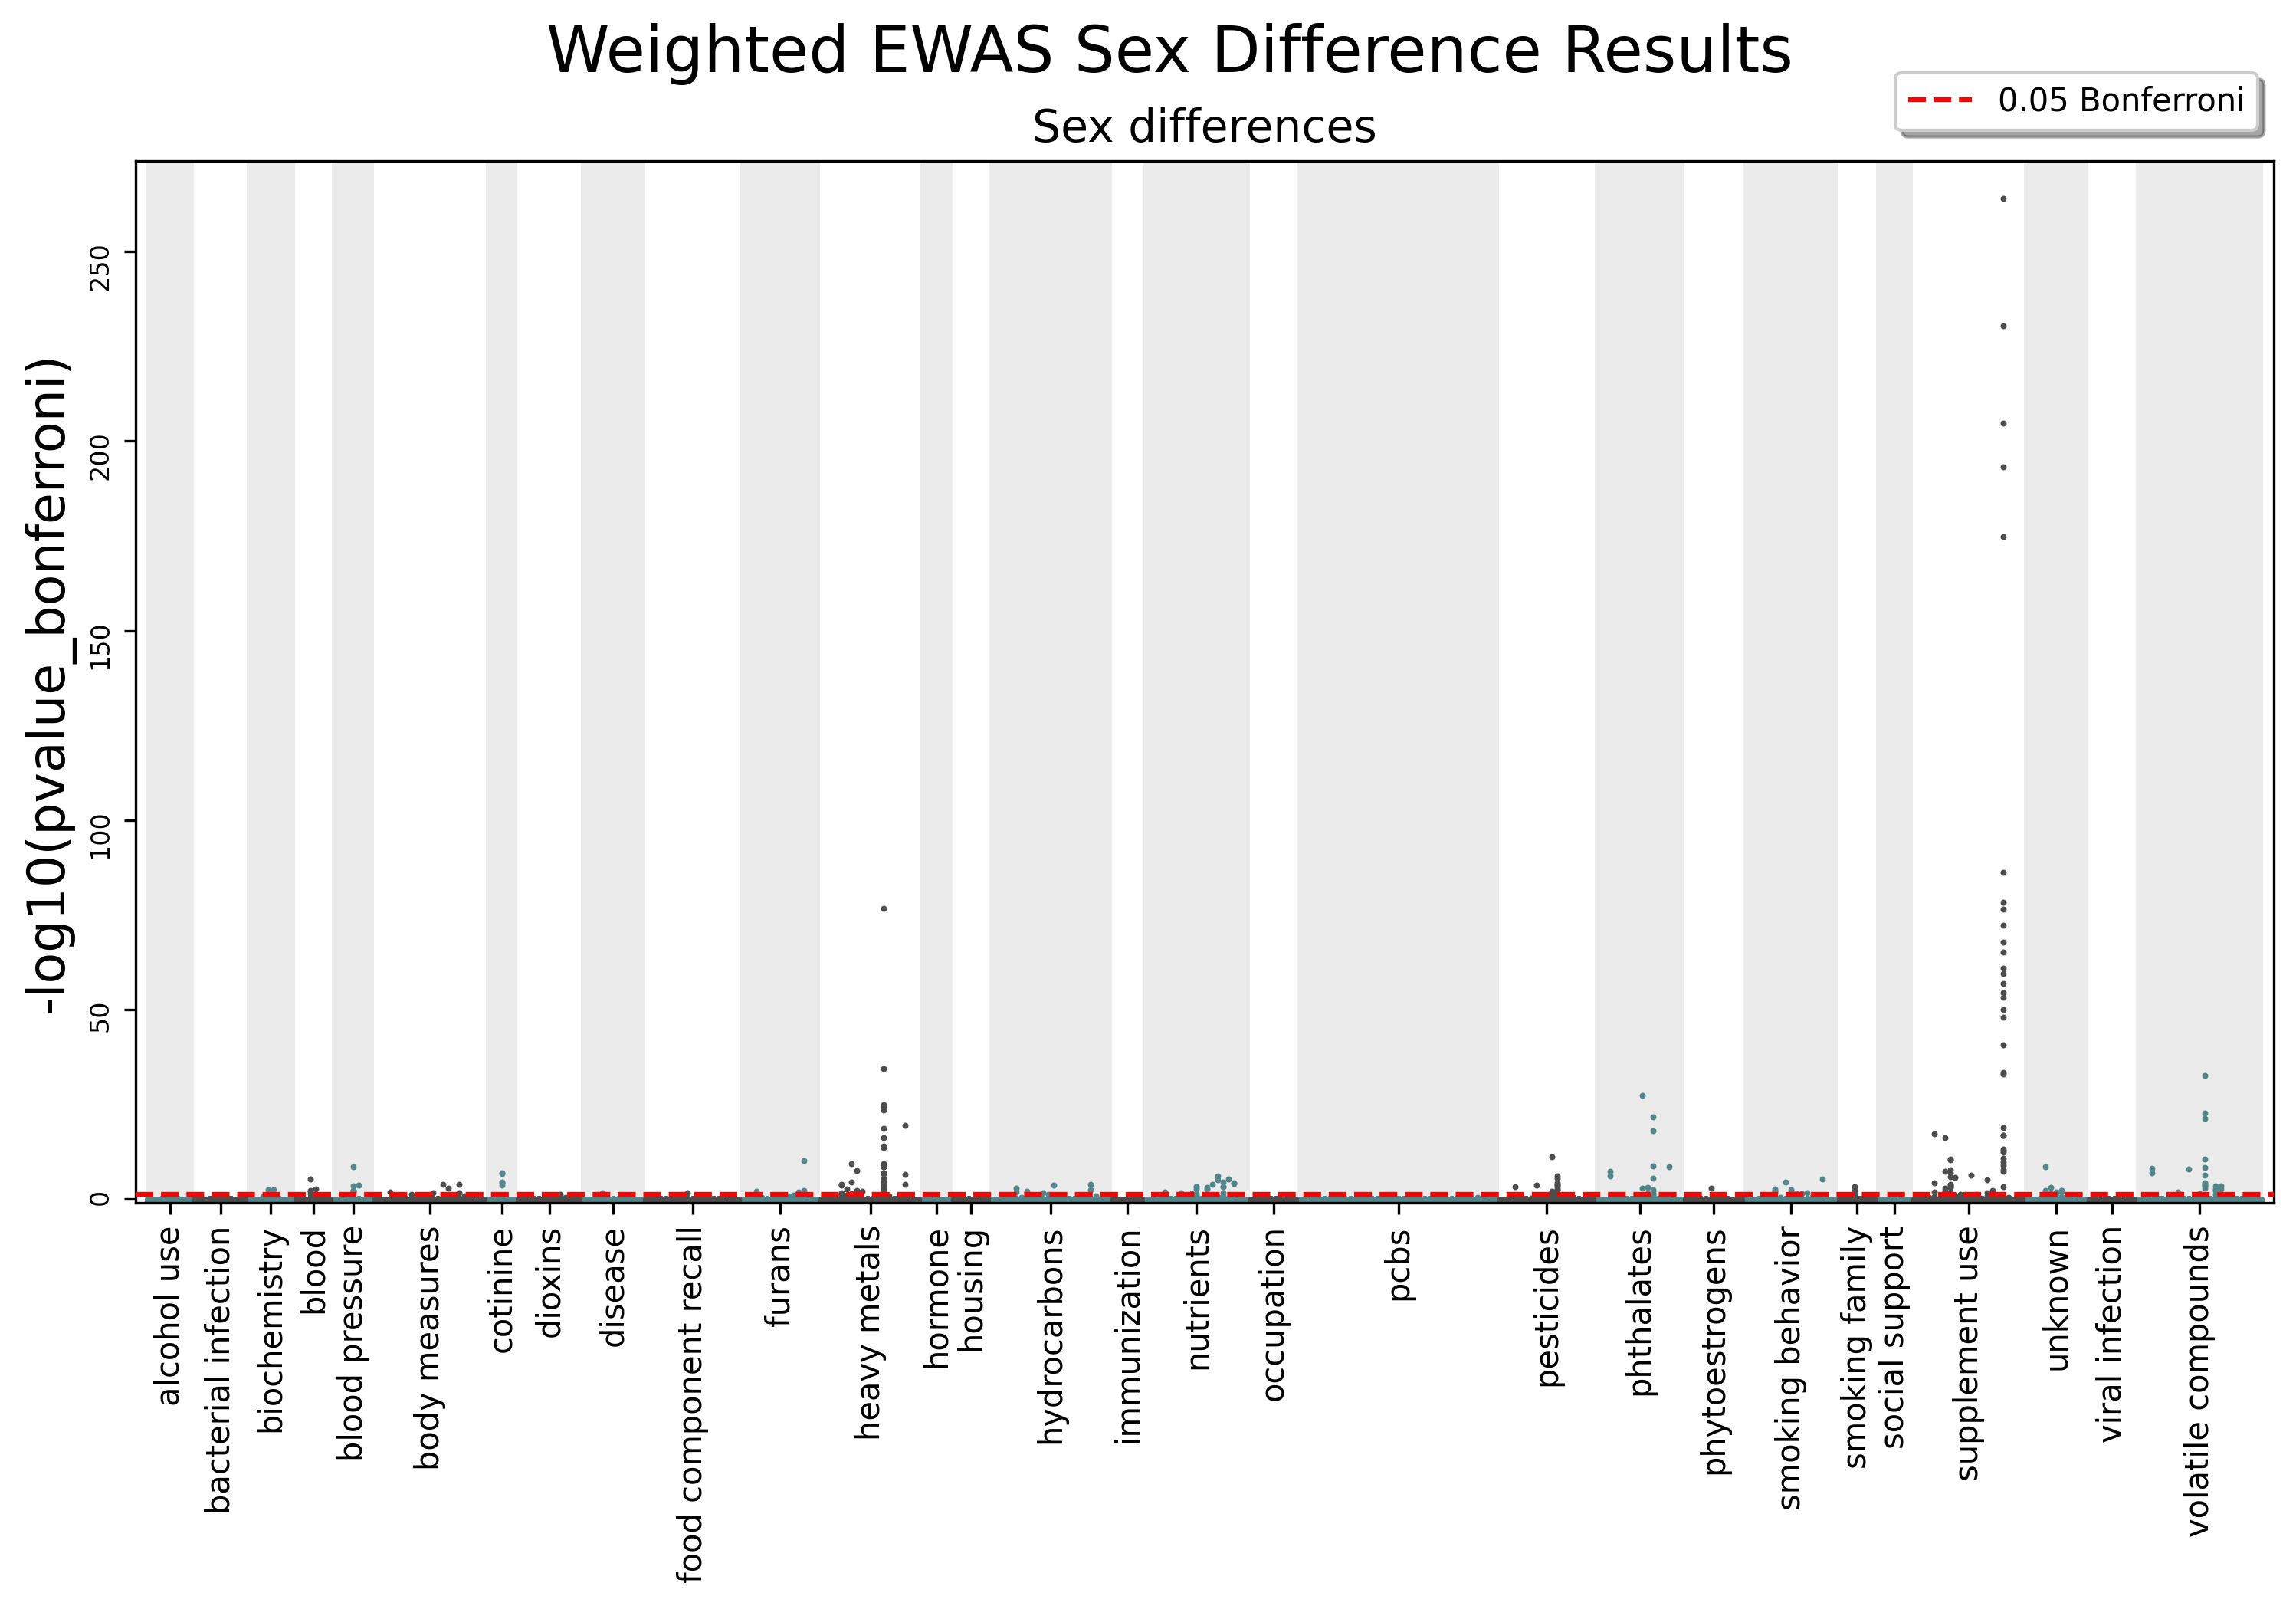

In [14]:
fig = plt.figure(figsize=(12,6), dpi=300)
cl.plot.manhattan_bonferroni({'Sex differences': plot_diff}, num_labeled=0,
                             categories=var_category, 
                             title="Weighted EWAS Sex Difference Results",
                             figure=fig)

## Effect size plots

In [38]:
from pySankey import sankey

In [47]:
i = [pd.Series(nhanes_qual.index.get_level_values('Variable')), pd.Series(nhanes_qual.index.get_level_values('Phenotype')) ]
vars_qual = pd.concat(i, axis=1)

In [48]:
vars_qual

,Variable,Phenotype
0,LBXODT,LBDMONO
1,LBXMIR,LBXMOPCT
2,URXP10,LBDHDL
3,LBXODT,LBXSLDSI
4,any_diabetes,LBXSUA
...,...,...
78,URXUPT,LBDNENO
79,URXMNP,LBXMCHSI
80,LBXLUZ,LBXMCVSI
81,LBXRBF,LBXSAL


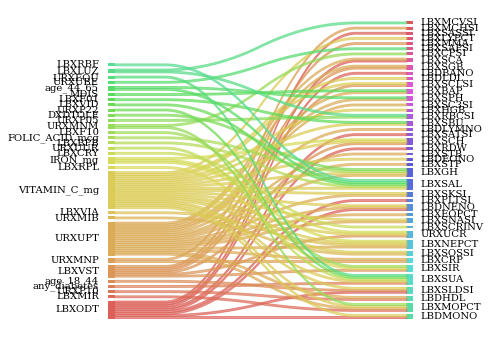

In [57]:
sankey.sankey(vars_qual['Variable'], vars_qual['Phenotype'], aspect=40, fontsize=10)

In [58]:
help(sankey.sankey)

Help on function sankey in module pySankey.sankey:

sankey(left, right, leftWeight=None, rightWeight=None, colorDict=None, leftLabels=None, rightLabels=None, aspect=4, rightColor=False, fontsize=14, figure_name=None, closePlot=False)
    Make Sankey Diagram showing flow from left-->right
    
    Inputs:
        left = NumPy array of object labels on the left of the diagram
        right = NumPy array of corresponding labels on the right of the diagram
            len(right) == len(left)
        leftWeight = NumPy array of weights for each strip starting from the
            left of the diagram, if not specified 1 is assigned
        rightWeight = NumPy array of weights for each strip starting from the
            right of the diagram, if not specified the corresponding leftWeight
            is assigned
        colorDict = Dictionary of colors to use for each label
            {'label':'color'}
        leftLabels = order of the left labels in the diagram
        rightLabels = order of

In [15]:
from FigureFun import *


In [16]:
nhanes_qual

,,Variable_type,Weight,Converged,N,LRT_pvalue,Diff_AIC,SE,Beta,pvalue,Variable_pvalue,...,SE_m,Beta_m,pvalue_m,Variable_pvalue_m,N_m,pvalue_diff,SE_diff,Beta_diff,Variable_pvalue_diff,pvalue_diff_bonferroni
Variable,Phenotype,,,,,,,,,,,,,,,,,,,,,
LBXODT,LBDMONO,continuous,NaN,True,3849.0,NaN,NaN,0.008912,-0.025198,0.000000e+00,0.000000e+00,...,0.015295,0.047953,1.717675e-03,1.717675e-03,1819.0,3.990612e-09,0.018820,-0.110747,3.990612e-09,4.841410e-05
LBXMIR,LBXMOPCT,continuous,NaN,True,4004.0,NaN,NaN,0.007461,0.032659,2.877629e-26,2.877629e-26,...,0.021171,-0.060391,4.336768e-03,4.336768e-03,1900.0,2.646401e-06,0.022622,0.106245,2.646401e-06,3.210614e-02
URXP10,LBDHDL,continuous,NaN,True,4184.0,NaN,NaN,0.041212,0.112421,5.822293e-21,5.822293e-21,...,0.042042,0.151810,3.051096e-04,3.051096e-04,2019.0,2.137732e-06,0.212700,-1.008185,2.137732e-06,2.593496e-02
LBXODT,LBXSLDSI,continuous,NaN,True,3870.0,NaN,NaN,0.005049,-0.001274,9.575260e-15,9.575260e-15,...,0.012232,-0.062258,3.582144e-07,3.582144e-07,1824.0,4.401557e-08,0.013429,0.073511,4.401557e-08,5.339969e-04
any_diabetes,LBXSUA,binary,NaN,True,17717.0,NaN,NaN,0.002694,-0.003531,1.034149e-11,1.034149e-11,...,0.004060,-0.017981,9.487975e-06,9.487975e-06,8544.0,1.973322e-06,0.005426,0.025808,1.973322e-06,2.394035e-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
URXUPT,LBDNENO,continuous,NaN,True,5879.0,NaN,NaN,0.171736,-1.035083,9.078479e-01,9.078479e-01,...,0.188893,-1.722654,7.529931e-20,7.529931e-20,2873.0,2.308465e-18,0.453607,3.965022,2.308465e-18,2.800630e-14
URXMNP,LBXMCHSI,continuous,NaN,True,5947.0,NaN,NaN,0.010634,-0.054006,9.128232e-01,9.128232e-01,...,0.012262,-0.098908,7.258500e-16,7.258500e-16,2864.0,1.918520e-13,0.024627,0.181117,1.918520e-13,2.327548e-09
LBXLUZ,LBXMCVSI,continuous,NaN,True,13872.0,NaN,NaN,0.009162,-0.022052,9.434682e-01,9.434682e-01,...,0.011123,-0.051431,3.765395e-06,3.765395e-06,6712.0,3.184907e-06,0.019617,0.091386,3.184907e-06,3.863929e-02


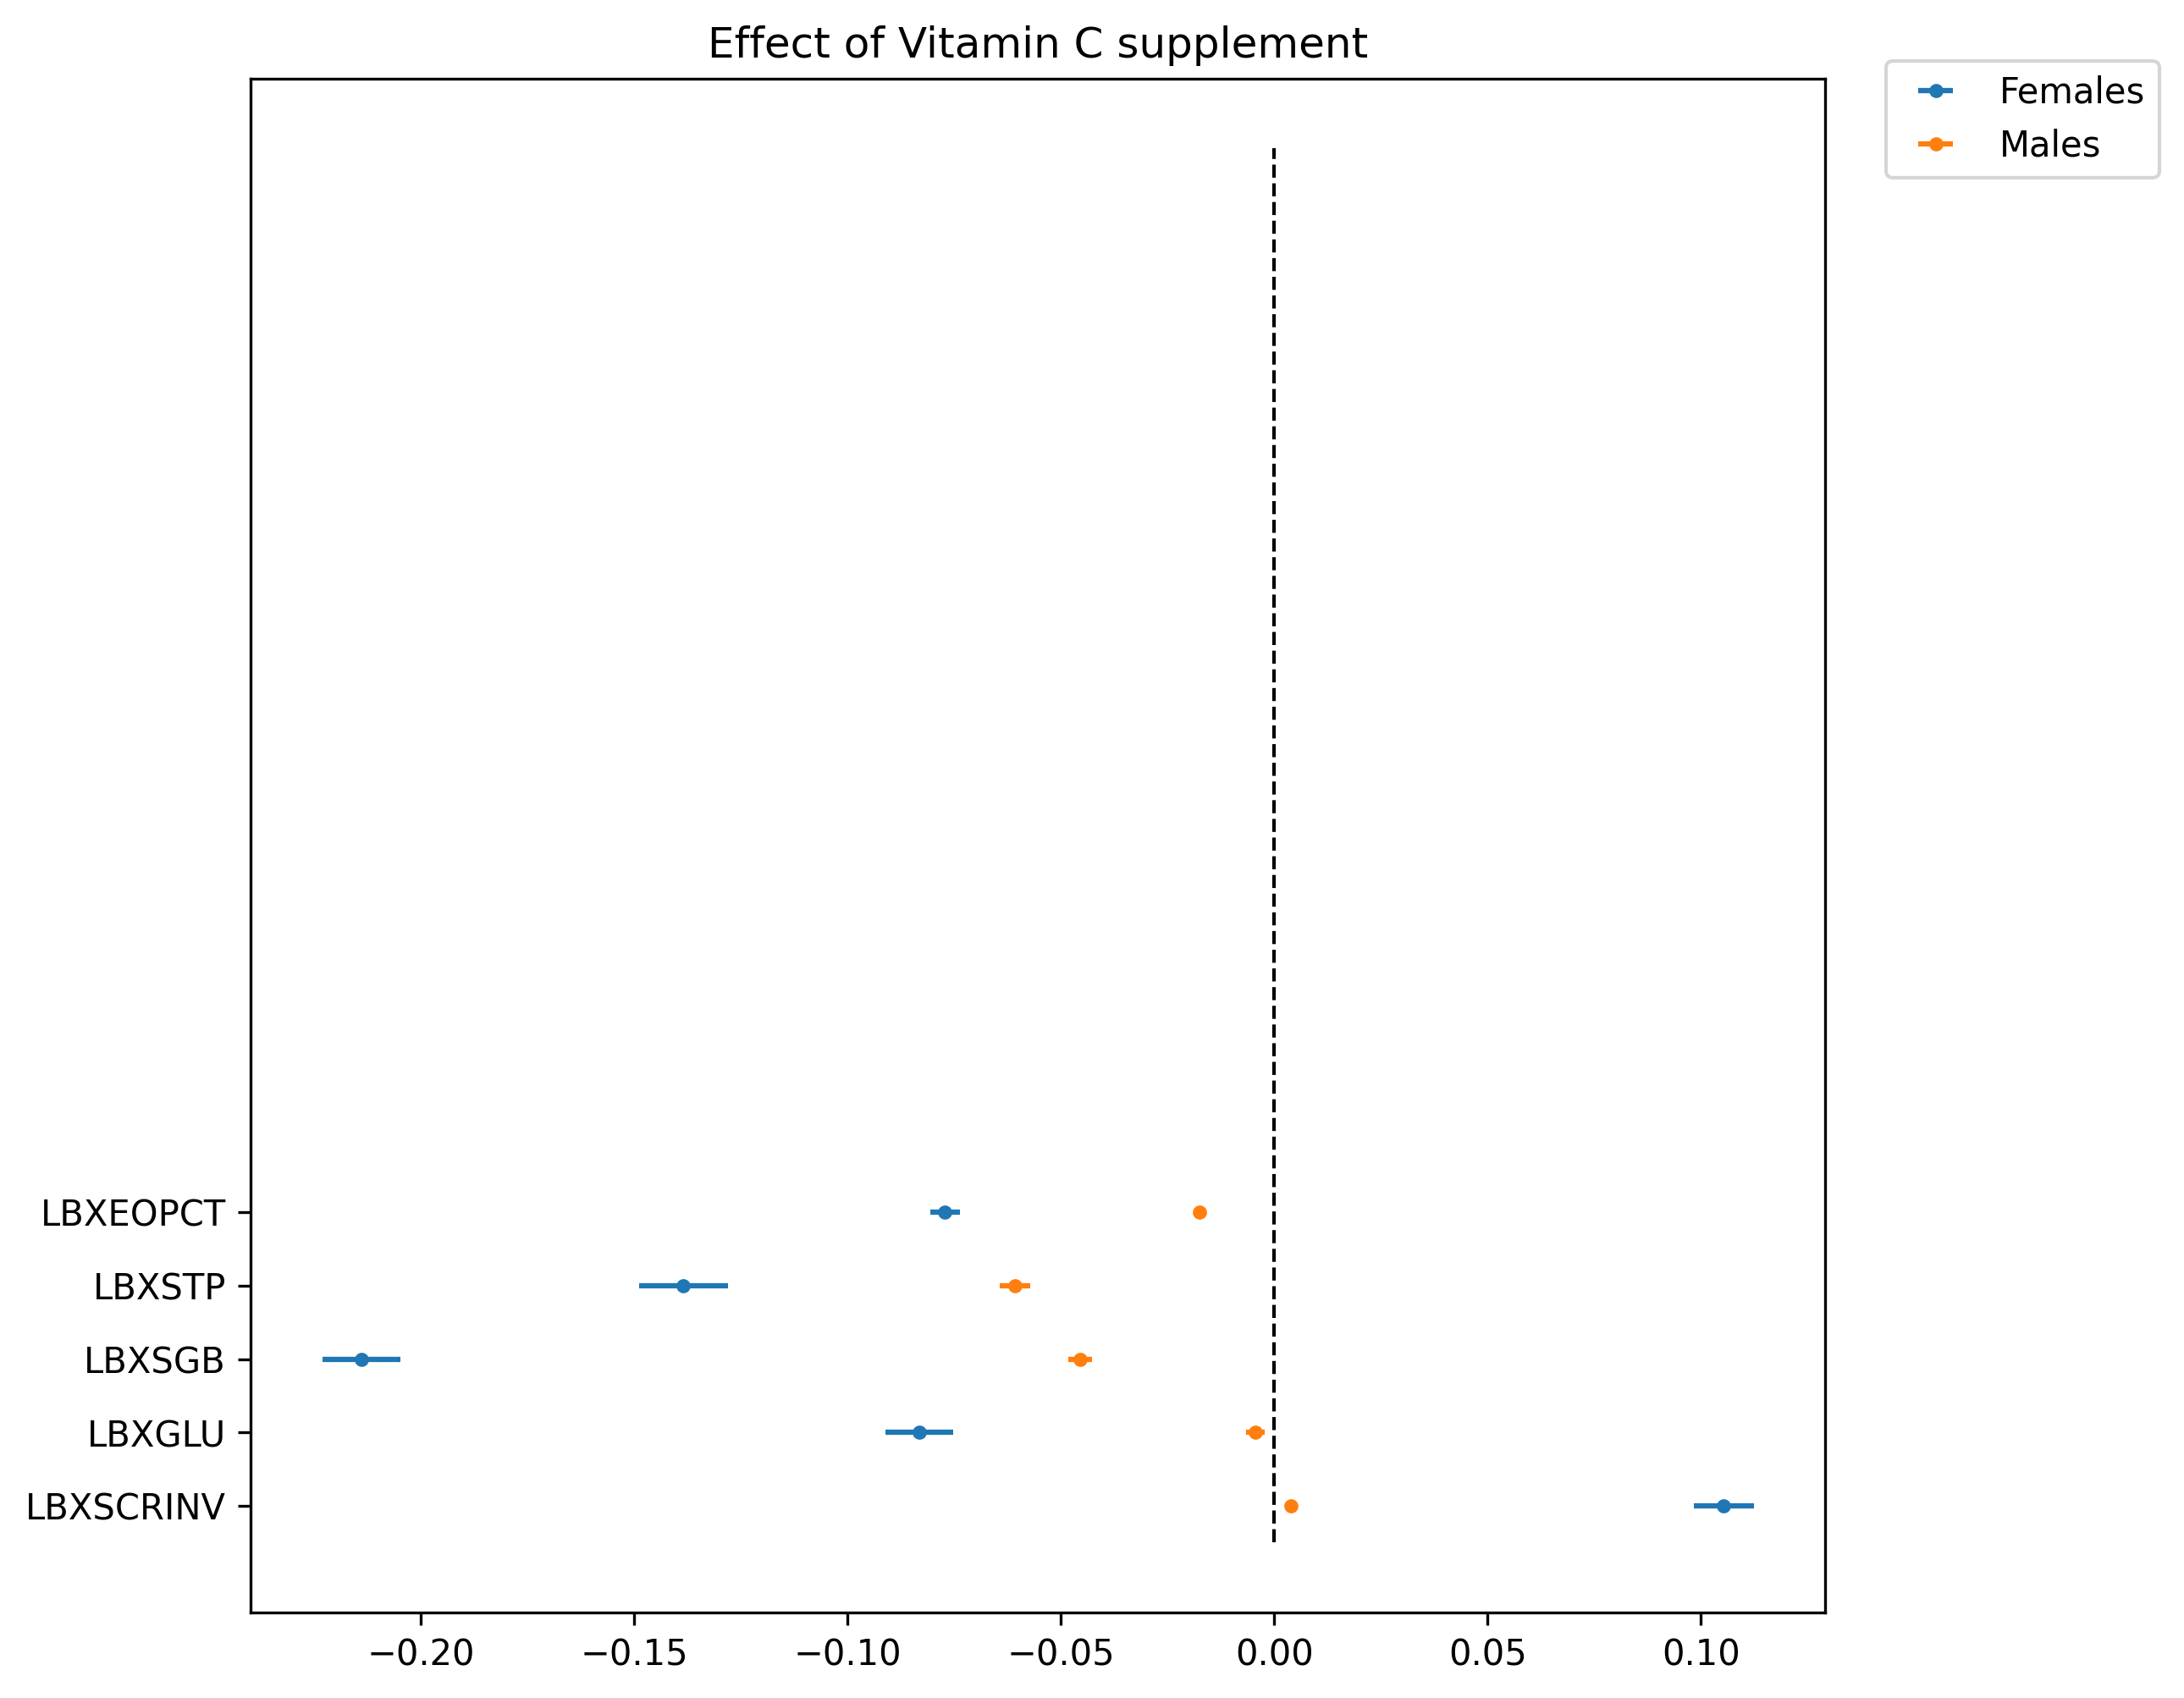

In [24]:
plot_betas(nhanes_quant, 'VITAMIN_C_mg', ci_names=['SE_f', 'SE_m'], vline_limits=[-0.5,18.5], title='Effect of Vitamin C supplement')

,,Variable_type,Weight,Converged,N,LRT_pvalue,Diff_AIC,SE,Beta,pvalue,Variable_pvalue,...,SE_m,Beta_m,pvalue_m,Variable_pvalue_m,N_m,pvalue_diff,SE_diff,Beta_diff,Variable_pvalue_diff,pvalue_diff_bonferroni
Variable,Phenotype,,,,,,,,,,,,,,,,,,,,,
any_diabetes,LBXSUA,binary,NaN,True,17717.0,NaN,NaN,0.002694,-0.003531,1.034149e-11,1.034149e-11,...,0.004060,-0.017981,9.487975e-06,9.487975e-06,8544.0,1.973322e-06,0.005426,0.025808,1.973322e-06,2.394035e-02
URXUUR,LBXSUA,continuous,NaN,True,4561.0,NaN,NaN,0.030963,0.070821,2.125648e-03,2.125648e-03,...,0.071943,0.729504,3.672337e-24,3.672337e-24,2225.0,3.558574e-24,0.079703,-0.808430,3.558574e-24,4.317262e-20
VITAMIN_C_mg,LBXSUA,continuous,NaN,True,17570.0,NaN,NaN,0.002658,0.042675,9.768588e-02,9.768588e-02,...,0.002802,0.049266,3.294286e-69,3.294286e-69,8539.0,9.658646e-14,0.008868,-0.066027,9.658646e-14,1.171787e-09
URXP22,LBXSUA,continuous,NaN,True,2878.0,NaN,NaN,0.013566,0.010113,1.759205e-01,1.759205e-01,...,0.022917,-0.094791,3.529481e-05,3.529481e-05,1392.0,1.349963e-08,0.028434,0.161495,1.349963e-08,1.637775e-04
URXEQU,LBXSUA,continuous,NaN,True,5673.0,NaN,NaN,0.018618,0.051207,8.710225e-01,8.710225e-01,...,0.065674,-0.282284,1.721623e-05,1.721623e-05,2732.0,1.189084e-07,0.068484,0.362633,1.189084e-07,1.442596e-03


In [110]:
list

,,Variable_type,Weight,Converged,N,LRT_pvalue,Diff_AIC,SE,Beta,pvalue,Variable_pvalue,...,SE_m,Beta_m,pvalue_m,Variable_pvalue_m,N_m,pvalue_diff,SE_diff,Beta_diff,Variable_pvalue_diff,pvalue_diff_bonferroni
Variable,Phenotype,,,,,,,,,,,,,,,,,,,,,
LBXODT,LBDMONO,continuous,NaN,True,3849.0,NaN,NaN,0.008912,-0.025198,0.000000e+00,0.000000e+00,...,0.015295,0.047953,1.717675e-03,1.717675e-03,1819.0,3.990612e-09,0.018820,-0.110747,3.990612e-09,4.841410e-05
LBXMIR,LBXMOPCT,continuous,NaN,True,4004.0,NaN,NaN,0.007461,0.032659,2.877629e-26,2.877629e-26,...,0.021171,-0.060391,4.336768e-03,4.336768e-03,1900.0,2.646401e-06,0.022622,0.106245,2.646401e-06,3.210614e-02
URXP10,LBDHDL,continuous,NaN,True,4184.0,NaN,NaN,0.041212,0.112421,5.822293e-21,5.822293e-21,...,0.042042,0.151810,3.051096e-04,3.051096e-04,2019.0,2.137732e-06,0.212700,-1.008185,2.137732e-06,2.593496e-02
LBXODT,LBXSLDSI,continuous,NaN,True,3870.0,NaN,NaN,0.005049,-0.001274,9.575260e-15,9.575260e-15,...,0.012232,-0.062258,3.582144e-07,3.582144e-07,1824.0,4.401557e-08,0.013429,0.073511,4.401557e-08,5.339969e-04
any_diabetes,LBXSUA,binary,NaN,True,17717.0,NaN,NaN,0.002694,-0.003531,1.034149e-11,1.034149e-11,...,0.004060,-0.017981,9.487975e-06,9.487975e-06,8544.0,1.973322e-06,0.005426,0.025808,1.973322e-06,2.394035e-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
URXUPT,LBDNENO,continuous,NaN,True,5879.0,NaN,NaN,0.171736,-1.035083,9.078479e-01,9.078479e-01,...,0.188893,-1.722654,7.529931e-20,7.529931e-20,2873.0,2.308465e-18,0.453607,3.965022,2.308465e-18,2.800630e-14
URXMNP,LBXMCHSI,continuous,NaN,True,5947.0,NaN,NaN,0.010634,-0.054006,9.128232e-01,9.128232e-01,...,0.012262,-0.098908,7.258500e-16,7.258500e-16,2864.0,1.918520e-13,0.024627,0.181117,1.918520e-13,2.327548e-09
LBXLUZ,LBXMCVSI,continuous,NaN,True,13872.0,NaN,NaN,0.009162,-0.022052,9.434682e-01,9.434682e-01,...,0.011123,-0.051431,3.765395e-06,3.765395e-06,6712.0,3.184907e-06,0.019617,0.091386,3.184907e-06,3.863929e-02


In [4]:
# Remove NaN pvalues
nhanes_res = nhanes_res.dropna(subset=['pvalue'])
nhanes_res = nhanes_res.sort_values(by='pvalue')
pt = 0.05/len(nhanes_res)

# Add a small value to the zeros
nhanes_res['pvalue'][0:3] = nhanes_res['pvalue'][0:3] + 3.810652e-253

# Add needed columns
nhanes_res['Variable_pvalue'] = nhanes_res['pvalue']
nhanes_res['Diff_AIC'] = nhanes_res['Diff_AIC_female']
nhanes_res['N'] = nhanes_res['N_female'] + nhanes_res['N_male']
nhanes_res['SE'] = np.sqrt(np.power(nhanes_res['SE_female'], 2) + np.power(nhanes_res['SE_male'], 2) )
nhanes_res['Variable_type'] = nhanes_res['Variable_type_female']
nhanes_res['LRT_pvalue'] = nhanes_res['LRT_pvalue_female']
nhanes_res['Beta'] = nhanes_res['Beta_female'] - nhanes_res['Beta_male']

nhanes_res['Converged'] = nhanes_res['Converged_female'] & nhanes_res['Converged_male']
cl.analyze.add_corrected_pvalues(nhanes_res)

/home/tomas/anaconda3/envs/py_clarite/lib/python3.7/site-packages/ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  import sys


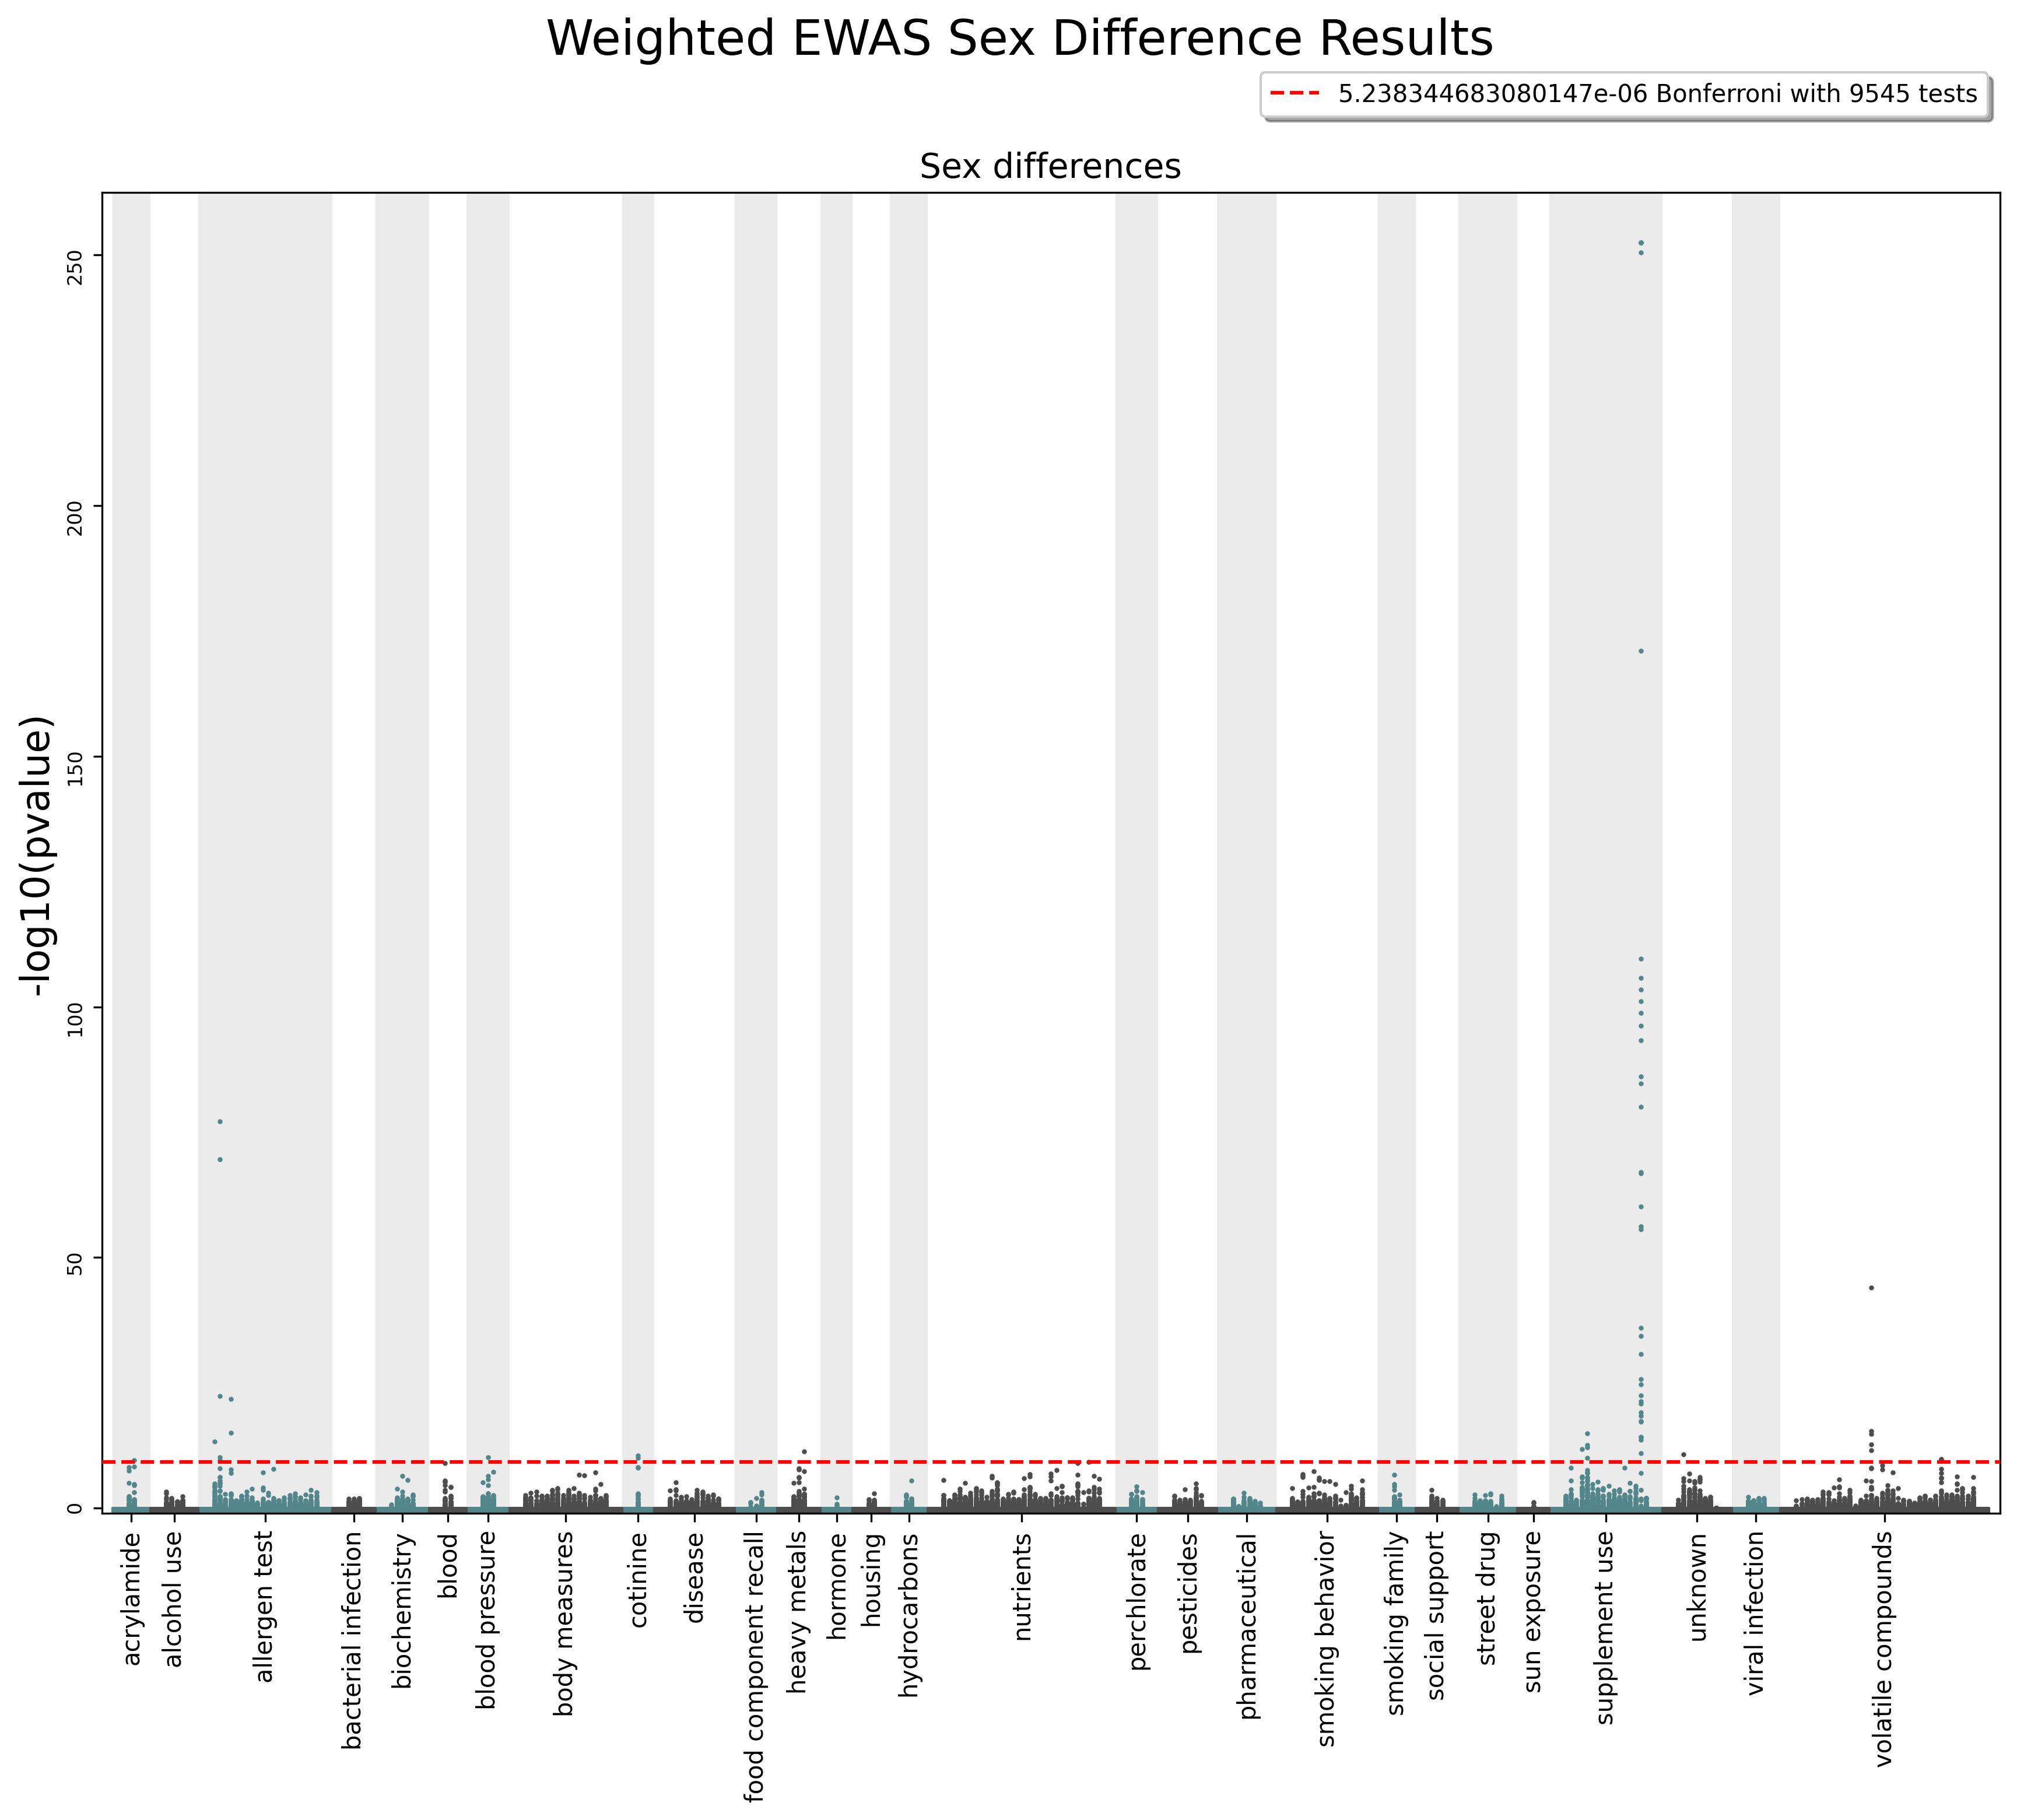

In [6]:
os.chdir(os.path.join(respath, 'Plots'))
cl.plot.manhattan({'Sex differences': nhanes_res}, bonferroni=pt, num_labeled=0,
                  categories=var_category, title="Weighted EWAS Sex Difference Results", 
                  filename= "ewas_plot.png", figsize=(14,10))

In [5]:
# Correct by multiple testing
pt = 0.05/len(nhanes_res)
nhanes_res = nhanes_res[nhanes_res['pvalue_difference'] < pt]